In [37]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Parametrii Digital Twin

In [38]:
GRID_SIZE = 150
D_O2 = 0.1 # coeficient de difuzie scalat pentru grid
LAMBDA_O2 = 0.044
O2_BOUNDARY = 220.0
O2_HYPOXIA = 10.0
O2_NECROSIS = 1.0
PROB_DIV_BASE = 0.04
DIFUSION_STEP = 1000


# Initialization Lattice

In [39]:
# Initialization Lattice
grid_celule = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)
grid_oxigen = np.full((GRID_SIZE, GRID_SIZE), O2_BOUNDARY, dtype=float)

mid = GRID_SIZE // 2

# Setăm raza inițială a agregatului celular (în număr de "pixeli/celule")
raza_initiala = 11

for i in range(GRID_SIZE):
    for j in range(GRID_SIZE):
        # Dacă distanța de la centru până la punctul (i,j) este mai mică decât raza, pune o celulă vie
        if (i - mid)**2 + (j - mid)**2 <= raza_initiala**2:
            grid_celule[i, j] = 1

ZILE_LAG_EFFECT = 11 # aprox 12 zile efect lag
ORE_LAG_EFFECT = ZILE_LAG_EFFECT * 24

# O2_DEF

In [40]:
def difuzie_oxigen(oxigen_vechi, celule):
    oxigen_nou = np.copy(oxigen_vechi)
    
    O_sus    = oxigen_vechi[:-2, 1:-1]
    O_jos    = oxigen_vechi[2:,  1:-1]
    O_stanga = oxigen_vechi[1:-1, :-2]
    O_dreapta= oxigen_vechi[1:-1, 2:]
    O_centru = oxigen_vechi[1:-1, 1:-1]
    
    # Laplacian discret calculat pentru toata grila in milisecunde
    laplacian = O_sus + O_jos + O_stanga + O_dreapta - 4 * O_centru
    
    # Consumul aplicat doar unde celulele au valoarea 1
    consum = np.where(celule[1:-1, 1:-1] == 1, LAMBDA_O2, 0.0)
    
    # Actualizam partea interioara a grilei dintr-un foc
    oxigen_nou[1:-1, 1:-1] = O_centru + (D_O2 * laplacian) - consum
    
    return np.clip(oxigen_nou, 0.0, O2_BOUNDARY)

# Biology Update

In [41]:

def update_biologie(celule, oxigen, ora):
    celule_noi = np.copy(celule)
    numar_celule = np.sum(celule > 0)

    # simulare efect lag
    if ora < ORE_LAG_EFFECT:
        PROB_DIV_BASE = 0.011
    else :
        PROB_DIV_BASE = 0.044

    for i in range(1, GRID_SIZE - 1):
        for j in range(1, GRID_SIZE - 1):
            if celule[i, j] == 1: # Celulă vie
                nivel_O2 = oxigen[i, j]
                
                # Regula 1: Necroza
                if nivel_O2 <= O2_NECROSIS:
                    celule_noi[i, j] = 2 
                    continue
                
                # Regula 2: Hipoxia
                if nivel_O2 <= O2_HYPOXIA:
                    continue 
                
                if np.random.rand() < PROB_DIV_BASE:
                    vecini_liberi = []
                    # Căutăm spațiu
                    if celule[i+1, j] == 0: vecini_liberi.append((i+1, j))
                    if celule[i-1, j] == 0: vecini_liberi.append((i-1, j))
                    if celule[i, j+1] == 0: vecini_liberi.append((i, j+1))
                    if celule[i, j-1] == 0: vecini_liberi.append((i, j-1))
                    
                    if vecini_liberi:
                        nou_i, nou_j = vecini_liberi[np.random.randint(len(vecini_liberi))]
                        celule_noi[nou_i, nou_j] = 1
                        
    return celule_noi

# Main Loop

In [42]:
zile_de_simulat = 35
ore_totale = zile_de_simulat * 24

istoric_volum = []
axa_timp = []

print("Simularea a inceput. Calculez...")
for ora in range(ore_totale):
    
    # Difuzia
    for _ in range(DIFUSION_STEP):
        grid_oxigen = difuzie_oxigen(grid_oxigen, grid_celule)
        
    grid_celule = update_biologie(grid_celule, grid_oxigen, ora)
    
    # Salvăm datele o dată la 24 de ore
    if ora % 24 == 0:
        ziua_curenta = ora // 24
        volum_curent = np.sum(grid_celule > 0) # Celule Vii + Necrotice
        
        istoric_volum.append(volum_curent)
        axa_timp.append(ziua_curenta)
        print(f"Ziua {ziua_curenta} finalizata | Volum: {volum_curent} celule")

# Salvăm ultima valoare
istoric_volum.append(np.sum(grid_celule > 0))
axa_timp.append(zile_de_simulat)

Simularea a inceput. Calculez...
Ziua 0 finalizata | Volum: 377 celule
Ziua 1 finalizata | Volum: 399 celule
Ziua 2 finalizata | Volum: 419 celule
Ziua 3 finalizata | Volum: 443 celule
Ziua 4 finalizata | Volum: 463 celule
Ziua 5 finalizata | Volum: 483 celule
Ziua 6 finalizata | Volum: 504 celule
Ziua 7 finalizata | Volum: 518 celule
Ziua 8 finalizata | Volum: 533 celule
Ziua 9 finalizata | Volum: 549 celule
Ziua 10 finalizata | Volum: 569 celule
Ziua 11 finalizata | Volum: 586 celule
Ziua 12 finalizata | Volum: 700 celule
Ziua 13 finalizata | Volum: 819 celule
Ziua 14 finalizata | Volum: 950 celule
Ziua 15 finalizata | Volum: 1072 celule
Ziua 16 finalizata | Volum: 1223 celule
Ziua 17 finalizata | Volum: 1389 celule
Ziua 18 finalizata | Volum: 1545 celule
Ziua 19 finalizata | Volum: 1718 celule
Ziua 20 finalizata | Volum: 1929 celule
Ziua 21 finalizata | Volum: 2115 celule
Ziua 22 finalizata | Volum: 2290 celule
Ziua 23 finalizata | Volum: 2537 celule
Ziua 24 finalizata | Volum: 2765

# Plotting

<>:9: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:9: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\david\AppData\Local\Temp\ipykernel_9624\2035262318.py:9: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax[1].set_title("Harta Oxigenului ($\mu$M)")


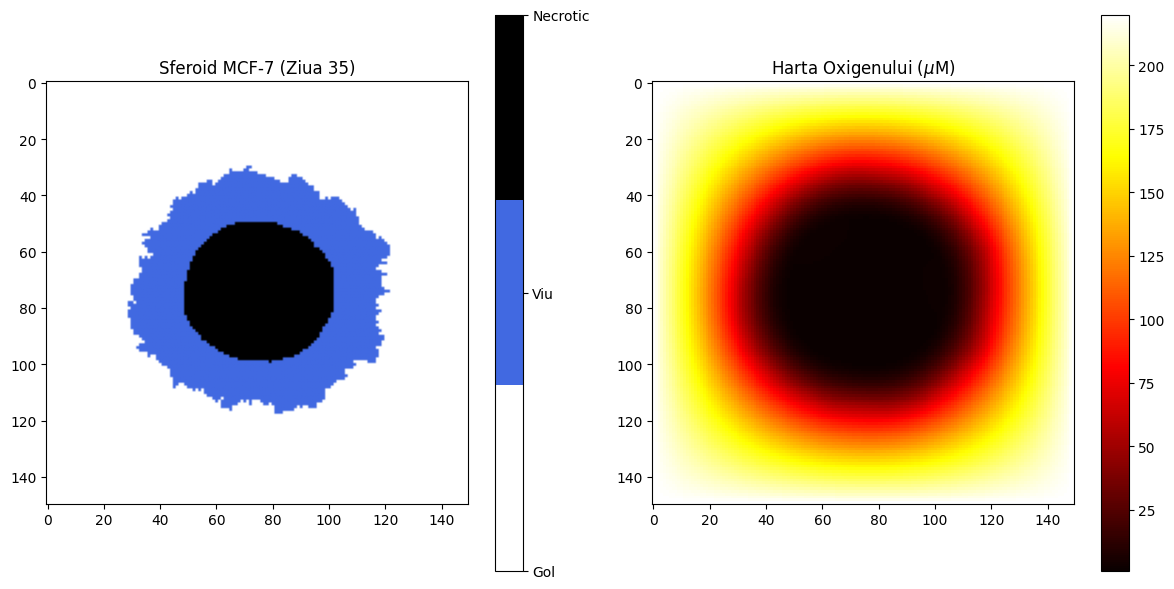

In [43]:
cmap_celule = mcolors.ListedColormap(['white', 'royalblue', 'black'])
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

im1 = ax[0].imshow(grid_celule, cmap=cmap_celule, vmin=0, vmax=2)
ax[0].set_title(f"Sferoid MCF-7 (Ziua {zile_de_simulat})")
fig.colorbar(im1, ax=ax[0], ticks=[0, 1, 2], format=plt.FuncFormatter(lambda val, loc: ['Gol', 'Viu', 'Necrotic'][val]))

im2 = ax[1].imshow(grid_oxigen, cmap='hot', interpolation='nearest')
ax[1].set_title("Harta Oxigenului ($\mu$M)")
fig.colorbar(im2, ax=ax[1])

plt.tight_layout()
plt.show()

# Conversie la volum

In [44]:

DIAMETRU_CELULA_UM = 20.0 # micrometri
RAZA_CELULA_UM = DIAMETRU_CELULA_UM / 2.0

aria_celula_um2 = np.pi * (RAZA_CELULA_UM ** 2)

def conversie_2D_in_Volum_3D(numar_celule):

    aria_totala_um2 = numar_celule * aria_celula_um2
    raza_sferoid_um = np.sqrt(aria_totala_um2 / np.pi)
    volum_um3 = (4/3) * np.pi * (raza_sferoid_um ** 3)
    
    # Conversie din micrometri cubi în milimetri cubi (1 mm³ = 10^9 µm³)
    volum_mm3 = volum_um3 / 1e9
    
    return volum_mm3

istoric_volum_mm3 = [conversie_2D_in_Volum_3D(n) for n in istoric_volum]

# Date reale

--- Performanța Digital Twin (Set Antrenare/Calibrare) ---
RMSE: 0.1943 mm³
Acuratețe calibrare: 71.26%



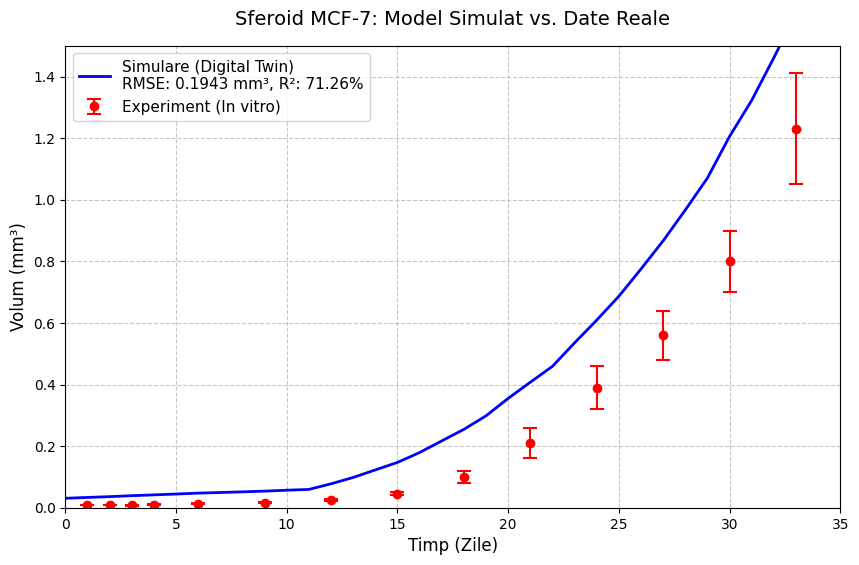

In [45]:
# Datele tale
zile_articol = np.array([1, 2, 3, 4, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33])
volum_articol_mm3 = np.array([0.009, 0.0085, 0.008, 0.0095, 0.013, 0.016, 0.024, 0.045, 0.10, 0.21, 0.39, 0.56, 0.80, 1.23])
erori_volum = np.array([0.001, 0.001, 0.001, 0.001, 0.001, 0.002, 0.003, 0.005, 0.02, 0.05, 0.07, 0.08, 0.10, 0.18])

volum_extras_mm3 = [istoric_volum_mm3[zi] for zi in zile_articol]
diferente_train = np.array(volum_extras_mm3)-volum_articol_mm3

rmse_train = np.sqrt(np.mean(diferente_train**2));
ss_res = np.sum(diferente_train**2)
ss_tot = np.sum((volum_articol_mm3-np.mean(volum_articol_mm3))**2)
r2_train = (1-(ss_res/ss_tot))*100

print(f"--- Performanța Digital Twin (Set Antrenare/Calibrare) ---")
print(f"RMSE: {rmse_train:.4f} mm³")
print(f"Acuratețe calibrare: {r2_train:.2f}%\n")
plt.figure(figsize=(10, 6))

plt.errorbar(
    x=zile_articol, 
    y=volum_articol_mm3, 
    yerr=erori_volum, 
    fmt='ro',             
    capsize=5,            
    capthick=1.5,         
    label='Experiment (In vitro)'
)

plt.plot(
    axa_timp, 
    istoric_volum_mm3, 
    'b-',                 
    linewidth=2,
    label=f'Simulare (Digital Twin)\nRMSE: {rmse_train:.4f} mm³, R²: {r2_train:.2f}%',
    zorder=2
)

plt.title('Sferoid MCF-7: Model Simulat vs. Date Reale', fontsize=14, pad=15)
plt.xlabel('Timp (Zile)', fontsize=12)
plt.ylabel('Volum (mm³)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper left', fontsize=11)

plt.xlim(0, 35) 
plt.ylim(0, 1.5) 

plt.show()

# Date validare

In [46]:
zile_validare = np.array([1, 3, 5, 8, 12, 16, 20, 24, 28, 32])
volum_validare_mm3 = np.array([0.035, 0.038, 0.042, 0.051, 0.090, 0.170, 0.320, 0.580, 0.950, 1.480])
erori_validare = np.array([0.002, 0.002, 0.003, 0.004, 0.008, 0.015, 0.030, 0.050, 0.080, 0.120])

# Gompertz

In [47]:
from scipy.optimize import curve_fit

def model_gompertz(t, V0, alpha, beta):
    return V0 * np.exp((alpha / beta) * (1 - np.exp(-beta * t)))

# face fitting direct pe datele verzi ca să găsească curba perfectă
parametri_optimi_val, covarianta_val = curve_fit(model_gompertz, zile_validare, volum_validare_mm3, p0=[0.035, 0.5, 0.05], maxfev=10000)

V0_opt_val, alpha_opt_val, beta_opt_val = parametri_optimi_val
print(f"--- Parametri Gompertz Optimi (Fitted pe Validare) ---")
print(f"V0: {V0_opt_val:.4f}, Alpha: {alpha_opt_val:.4f}, Beta: {beta_opt_val:.4f}")

curba_gompertz_val = model_gompertz(np.array(axa_timp), V0_opt_val, alpha_opt_val, beta_opt_val)

--- Parametri Gompertz Optimi (Fitted pe Validare) ---
V0: 0.0098, Alpha: 0.2169, Beta: 0.0214


# Plot validare

--- Performanța PREDICTIVĂ Digital Twin (Set Validare) ---
RMSE: 0.0171 mm³
Acuratețe predictivă: 94.76%



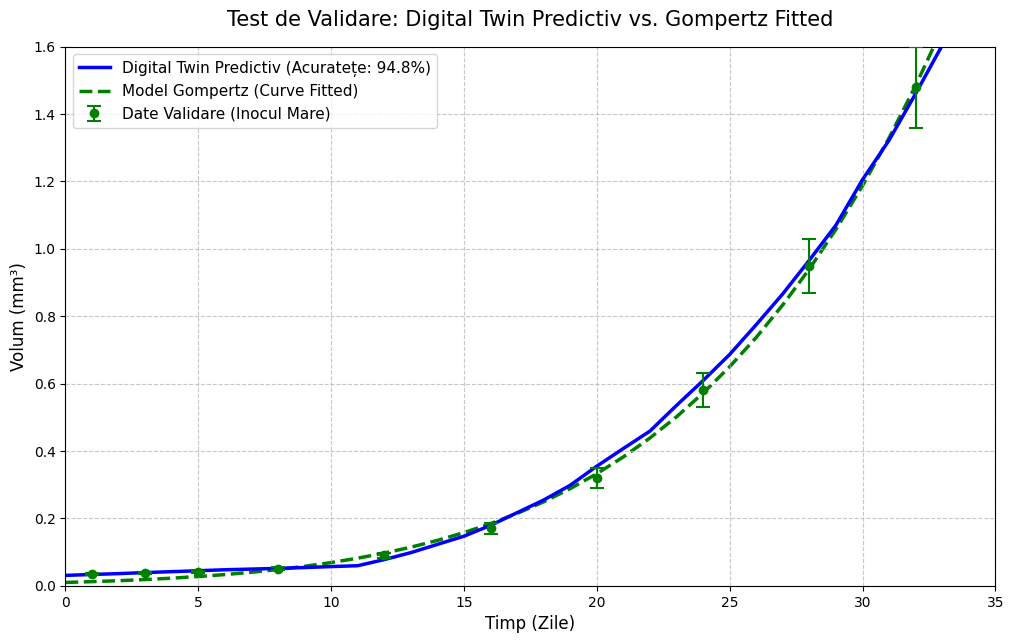

In [48]:
import numpy as np
import matplotlib.pyplot as plt

valori_simulate_extrase_val = [istoric_volum_mm3[zi] for zi in zile_validare]
diferente_val = np.array(valori_simulate_extrase_val) - volum_validare_mm3

# Calcul RMSE
rmse_dt_val = np.sqrt(np.mean(diferente_val**2))

# Calcul Eroare Medie Procentuală Absolută 
mape_dt_val = np.mean(np.abs(diferente_val) / volum_validare_mm3) * 100
acuratete_dt_val = 100 - mape_dt_val

print(f"--- Performanța PREDICTIVĂ Digital Twin (Set Validare) ---")
print(f"RMSE: {rmse_dt_val:.4f} mm³")
print(f"Acuratețe predictivă: {acuratete_dt_val:.2f}%\n")

plt.figure(figsize=(12, 7))
plt.errorbar(zile_validare, volum_validare_mm3, yerr=erori_validare, fmt='go', capsize=5, capthick=1.5, label='Date Validare (Inocul Mare)', zorder=3)
plt.plot(axa_timp, istoric_volum_mm3, 'b-', linewidth=2.5, label=f'Digital Twin Predictiv (Acuratețe: {acuratete_dt_val:.1f}%)', zorder=2)
plt.plot(axa_timp, curba_gompertz_val, 'g--', linewidth=2.5, label='Model Gompertz (Curve Fitted)', zorder=1)
plt.title('Test de Validare: Digital Twin Predictiv vs. Gompertz Fitted', fontsize=15, pad=15)
plt.xlabel('Timp (Zile)', fontsize=12)
plt.ylabel('Volum (mm³)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper left', fontsize=11)
plt.xlim(0, 35)
plt.ylim(0, 1.6)

plt.show()